# Bootstrap — Intervalos de Confiança 95%
Estima a incerteza das métricas via reamostramento com reposição do conjunto de teste (2024).
Método: percentil (2.5% e 97.5% da distribuição bootstrap).
**Métricas:** Sensibilidade · AUPRC · ROC-AUC

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, average_precision_score, roc_auc_score
)

OUTPUT_MET  = '../../output/metricas'
OUTPUT_PLT  = '../../output/plots'
N_BOOTSTRAP = 2000
RANDOM_STATE = 42
os.makedirs(OUTPUT_PLT, exist_ok=True)

LABEL_MAP = {
    'logistic_regression_baseline':          'LR',
    'logistic_regression_baseline_tuned':    'LR (tuned)',
    'lightgbm_baseline':                     'LightGBM',
    'lightgbm_baseline_tuned':               'LightGBM (tuned)',
    'xgboost_baseline':                      'XGBoost',
    'xgboost_baseline_tuned':               'XGBoost (tuned)',
    'random_forest_baseline':                'Random Forest',
    'random_forest_baseline_tuned':          'Random Forest (tuned)',
    'decision_tree_baseline':                'Decision Tree',
    'decision_tree_baseline_tuned':          'Decision Tree (tuned)',
}

## 1. Carregamento das predições

In [2]:
predicoes = {}
for f in sorted(os.listdir(OUTPUT_MET)):
    if not f.endswith('_predicoes.parquet'):
        continue
    base = f.replace('_predicoes.parquet', '')
    if base not in LABEL_MAP:
        continue
    df   = pd.read_parquet(os.path.join(OUTPUT_MET, f))
    predicoes[base] = {
        'label':   LABEL_MAP[base],
        'y_true':  df['y_true'].values,
        'y_proba': df['y_proba'].values,
    }

print(f'{len(predicoes)} modelos carregados:')
for k, v in predicoes.items():
    print(f'  {v["label"]:<35} n={len(v["y_true"]):,}  óbitos={v["y_true"].sum():,}')

10 modelos carregados:
  Decision Tree                       n=160,534  óbitos=5,295.0
  Decision Tree (tuned)               n=160,534  óbitos=5,295.0
  LightGBM                            n=160,534  óbitos=5,295.0
  LightGBM (tuned)                    n=160,534  óbitos=5,295.0
  LR                                  n=160,534  óbitos=5,295.0
  LR (tuned)                          n=160,534  óbitos=5,295.0
  Random Forest                       n=160,534  óbitos=5,295.0
  Random Forest (tuned)               n=160,534  óbitos=5,295.0
  XGBoost                             n=160,534  óbitos=5,295.0
  XGBoost (tuned)                     n=160,534  óbitos=5,295.0


## 2. Função de bootstrap

Usa `scipy.stats.bootstrap` com `paired=True` para manter y_true e y_proba alinhados no resample.  
O atributo `.bootstrap_distribution` retorna as N estatísticas geradas — mesma estrutura do loop manual.

In [3]:
from scipy.stats import bootstrap as scipy_bootstrap

def _sensibilidade(y_true, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, (y_proba >= 0.5).astype(int)).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

ESTATISTICAS = {
    'sensibilidade': _sensibilidade,
    'auprc':         average_precision_score,
    'roc_auc':       roc_auc_score,
}

def bootstrap_metricas(y_true, y_proba, n=N_BOOTSTRAP, seed=RANDOM_STATE):
    resultados = {}
    for nome, func in ESTATISTICAS.items():
        res = scipy_bootstrap(
            (y_true, y_proba),
            statistic=func,
            n_resamples=n,
            paired=True,
            random_state=seed,
            method='percentile',
        )
        resultados[nome] = res.bootstrap_distribution
    return pd.DataFrame(resultados)

## 3. Execução do bootstrap (≈ alguns minutos)

In [4]:
# Carrega distribuições já computadas para evitar re-execução
dist_path = os.path.join(OUTPUT_MET, 'bootstrap_distribuicoes.parquet')
if os.path.exists(dist_path):
    df_dist_cache = pd.read_parquet(dist_path)
    labels_em_cache = set(df_dist_cache['modelo'].unique())
else:
    df_dist_cache = pd.DataFrame()
    labels_em_cache = set()

resultados_bs = {}

for arquivo, info in predicoes.items():
    label = info['label']
    if label in labels_em_cache:
        sub = df_dist_cache[df_dist_cache['modelo'] == label][['sensibilidade', 'auprc', 'roc_auc']]
        resultados_bs[arquivo] = sub.reset_index(drop=True)
        print(f'Carregado do cache: {label}')
    else:
        print(f'Bootstrap: {label}...', end=' ', flush=True)
        dist = bootstrap_metricas(info['y_true'], info['y_proba'])
        resultados_bs[arquivo] = dist
        print('OK')

print(f'\nConcluído — {N_BOOTSTRAP} iterações por modelo.')

Bootstrap: Decision Tree... OK
Bootstrap: Decision Tree (tuned)... OK
Bootstrap: LightGBM... OK
Bootstrap: LightGBM (tuned)... OK
Bootstrap: LR... OK
Bootstrap: LR (tuned)... OK
Bootstrap: Random Forest... OK
Bootstrap: Random Forest (tuned)... OK
Bootstrap: XGBoost... OK
Bootstrap: XGBoost (tuned)... OK

Concluído — 2000 iterações por modelo.


## 4. Tabela de IC 95%

In [5]:
rows = []
for arquivo, dist in resultados_bs.items():
    info = predicoes[arquivo]
    y_true, y_proba = info['y_true'], info['y_proba']

    # estimativa pontual (conjunto completo)
    tn, fp, fn, tp = confusion_matrix(y_true, (y_proba >= 0.5).astype(int)).ravel()
    sens_pt  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    auprc_pt = average_precision_score(y_true, y_proba)
    roc_pt   = roc_auc_score(y_true, y_proba)

    for metrica, pt in [('sensibilidade', sens_pt), ('auprc', auprc_pt), ('roc_auc', roc_pt)]:
        lo = dist[metrica].quantile(0.025)
        hi = dist[metrica].quantile(0.975)
        rows.append({
            'modelo':   info['label'],
            'metrica':  metrica,
            'estimativa': round(pt, 4),
            'ic_low':   round(lo, 4),
            'ic_high':  round(hi, 4),
            'ic_width': round(hi - lo, 4),
        })

df_ic = pd.DataFrame(rows)

# tabela pivotada por métrica
for metrica in ['sensibilidade', 'auprc', 'roc_auc']:
    sub = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=False)
        [['modelo', 'estimativa', 'ic_low', 'ic_high', 'ic_width']]
        .reset_index(drop=True)
    )
    sub['IC 95%'] = sub.apply(lambda r: f"[{r['ic_low']:.4f}, {r['ic_high']:.4f}]", axis=1)
    print(f'\n=== {metrica.upper()} ===')
    display(sub[['modelo', 'estimativa', 'IC 95%', 'ic_width']])


=== SENSIBILIDADE ===


,modelo,estimativa,IC 95%,ic_width
0,LR (tuned),0.8130,"[0.8029, 0.8229]",0.0199
1,LR,0.8127,"[0.8024, 0.8225]",0.0201
2,XGBoost (tuned),0.7941,"[0.7833, 0.8046]",0.0213
3,XGBoost,0.7505,"[0.7387, 0.7611]",0.0224
4,LightGBM (tuned),0.7488,"[0.7376, 0.7599]",0.0223
5,Decision Tree,0.7394,"[0.7278, 0.7507]",0.0229
6,Decision Tree (tuned),0.7347,"[0.7231, 0.7469]",0.0238
7,LightGBM,0.6825,"[0.6701, 0.6951]",0.0251
8,Random Forest,0.6240,"[0.6113, 0.6369]",0.0256
9,Random Forest (tuned),0.4444,"[0.4314, 0.4580]",0.0267



=== AUPRC ===


,modelo,estimativa,IC 95%,ic_width
0,XGBoost (tuned),0.6291,"[0.6157, 0.6421]",0.0264
1,Random Forest,0.6284,"[0.6153, 0.6411]",0.0258
2,Random Forest (tuned),0.6281,"[0.6149, 0.6408]",0.0259
3,LightGBM (tuned),0.6264,"[0.6132, 0.6392]",0.0260
4,LR (tuned),0.6248,"[0.6109, 0.6383]",0.0274
5,LR,0.6246,"[0.6107, 0.6381]",0.0274
6,XGBoost,0.6113,"[0.5979, 0.6249]",0.0270
7,LightGBM,0.6104,"[0.5966, 0.6234]",0.0268
8,Decision Tree (tuned),0.5685,"[0.5547, 0.5822]",0.0274
9,Decision Tree,0.5523,"[0.5377, 0.5665]",0.0288



=== ROC_AUC ===


,modelo,estimativa,IC 95%,ic_width
0,LR (tuned),0.9236,"[0.9193, 0.9275]",0.0082
1,LR,0.9235,"[0.9193, 0.9275]",0.0082
2,Random Forest,0.9196,"[0.9153, 0.9237]",0.0084
3,XGBoost (tuned),0.9175,"[0.9132, 0.9219]",0.0088
4,LightGBM (tuned),0.9106,"[0.9059, 0.9153]",0.0093
5,XGBoost,0.9075,"[0.9028, 0.9121]",0.0094
6,Random Forest (tuned),0.9041,"[0.8987, 0.9092]",0.0105
7,LightGBM,0.9015,"[0.8966, 0.9064]",0.0098
8,Decision Tree (tuned),0.8845,"[0.8788, 0.8902]",0.0114
9,Decision Tree,0.8761,"[0.8698, 0.8824]",0.0126


## 5. Forest plot — IC 95% por métrica

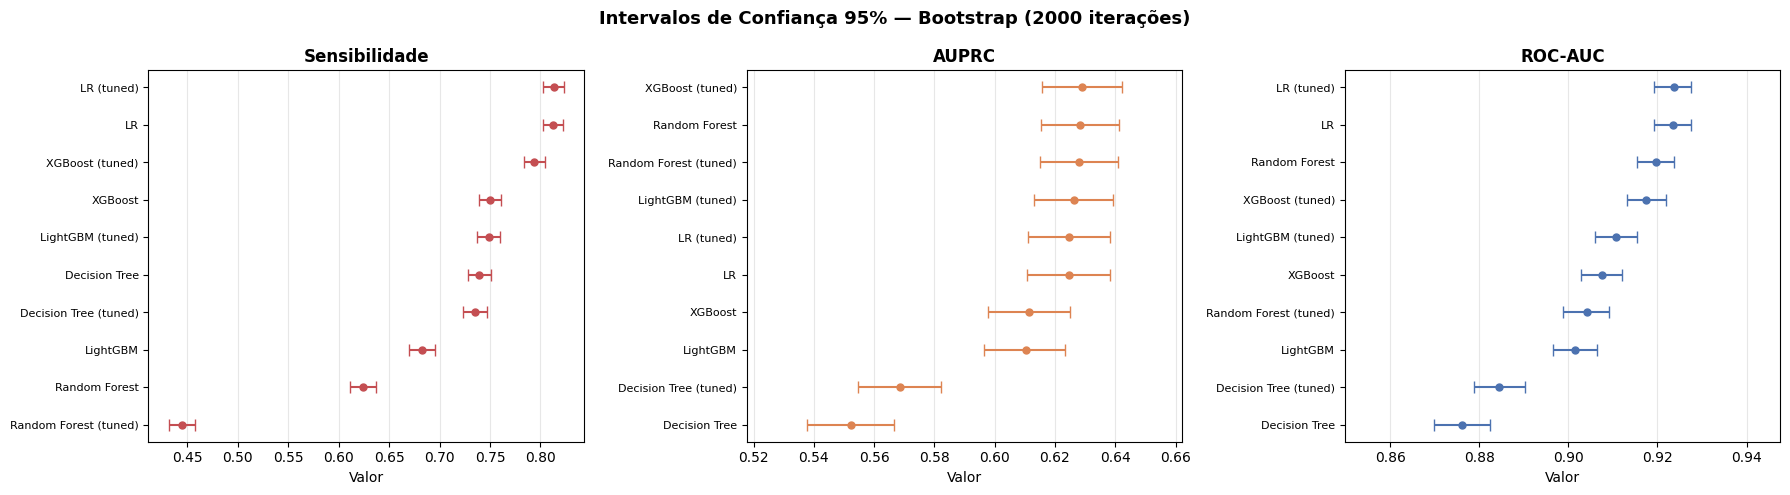

In [6]:
metricas_plot = [
    ('sensibilidade', '#C44E52', 'Sensibilidade'),
    ('auprc',         '#DD8452', 'AUPRC'),
    ('roc_auc',       '#4C72B0', 'ROC-AUC'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(predicoes) * 0.5)))

for ax, (metrica, cor, titulo) in zip(axes, metricas_plot):
    sub = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=True)
        .reset_index(drop=True)
    )
    y_pos = np.arange(len(sub))

    xerr_lo = sub['estimativa'] - sub['ic_low']
    xerr_hi = sub['ic_high']   - sub['estimativa']

    ax.errorbar(
        sub['estimativa'], y_pos,
        xerr=[xerr_lo, xerr_hi],
        fmt='o', color=cor, ecolor=cor, elinewidth=1.5,
        capsize=4, markersize=5,
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['modelo'], fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(
        max(0, sub['ic_low'].min() - 0.02),
        min(1, sub['ic_high'].max() + 0.02),
    )

plt.suptitle(f'Intervalos de Confiança 95% — Bootstrap ({N_BOOTSTRAP} iterações)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_forest_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribuição bootstrap — top modelos

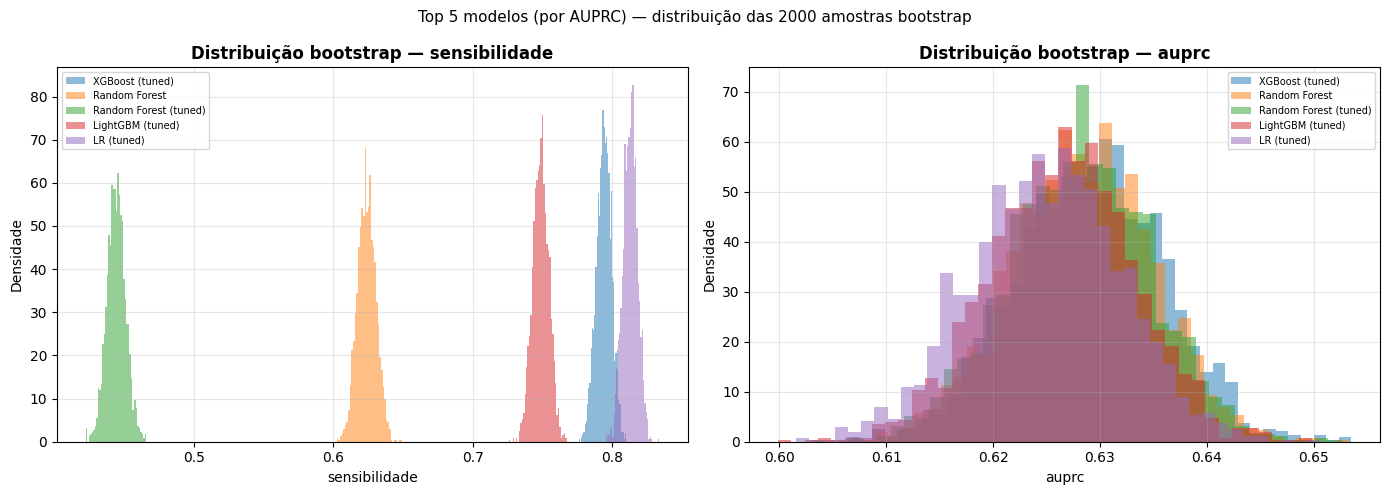

In [7]:
# Seleciona top 5 por AUPRC para visualizar a distribuição
top5 = (
    df_ic[df_ic['metrica'] == 'auprc']
    .sort_values('estimativa', ascending=False)
    .head(5)['modelo']
    .tolist()
)

arquivo_por_label = {v['label']: k for k, v in predicoes.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrica in zip(axes, ['sensibilidade', 'auprc']):
    for label in top5:
        arq  = arquivo_por_label[label]
        dist = resultados_bs[arq][metrica]
        ax.hist(dist, bins=40, alpha=0.5, label=label, density=True)
    ax.set_title(f'Distribuição bootstrap — {metrica}', fontweight='bold')
    ax.set_xlabel(metrica)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(f'Top 5 modelos (por AUPRC) — distribuição das {N_BOOTSTRAP} amostras bootstrap',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_distribuicoes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparação pareada — sobreposição de ICs
Dois modelos são considerados **estatisticamente distinguíveis** se seus ICs 95% não se sobrepõem (teste conservador).

In [8]:
from itertools import combinations

for metrica in ['sensibilidade', 'auprc']:
    sub = df_ic[df_ic['metrica'] == metrica].set_index('modelo')
    modelos_ord = sub.sort_values('estimativa', ascending=False).index.tolist()

    print(f'\n=== Diferenças significativas — {metrica.upper()} ===')
    encontrou = False
    for m1, m2 in combinations(modelos_ord, 2):
        lo1, hi1 = sub.loc[m1, 'ic_low'], sub.loc[m1, 'ic_high']
        lo2, hi2 = sub.loc[m2, 'ic_low'], sub.loc[m2, 'ic_high']
        # ICs não se sobrepõem
        if hi1 < lo2 or hi2 < lo1:
            est1, est2 = sub.loc[m1, 'estimativa'], sub.loc[m2, 'estimativa']
            melhor = m1 if est1 > est2 else m2
            print(f'  {m1} vs {m2} → distinguíveis (melhor: {melhor})')
            encontrou = True
    if not encontrou:
        print('  Nenhum par com ICs não sobrepostos — diferenças não são estatisticamente distinguíveis.')


=== Diferenças significativas — SENSIBILIDADE ===
  LR (tuned) vs XGBoost → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs LightGBM (tuned) → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Decision Tree → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Decision Tree (tuned) → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs LightGBM → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Random Forest → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Random Forest (tuned) → distinguíveis (melhor: LR (tuned))
  LR vs XGBoost → distinguíveis (melhor: LR)
  LR vs LightGBM (tuned) → distinguíveis (melhor: LR)
  LR vs Decision Tree → distinguíveis (melhor: LR)
  LR vs Decision Tree (tuned) → distinguíveis (melhor: LR)
  LR vs LightGBM → distinguíveis (melhor: LR)
  LR vs Random Forest → distinguíveis (melhor: LR)
  LR vs Random Forest (tuned) → distinguíveis (melhor: LR)
  XGBoost (tuned) vs XGBoost → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) vs LightGBM (tuned

## 8. Salvamento

In [9]:
os.makedirs(OUTPUT_MET, exist_ok=True)

# Resumo dos ICs
ic_path = os.path.join(OUTPUT_MET, 'bootstrap_ic95.csv')
df_ic.to_csv(ic_path, index=False)
print(f'ICs salvos: {ic_path}')

# Distribuições brutas (1 linha por iteração por modelo)
dist_rows = []
for arquivo, dist in resultados_bs.items():
    df_temp = dist.copy()
    df_temp['modelo'] = predicoes[arquivo]['label']
    dist_rows.append(df_temp)

df_dist = pd.concat(dist_rows, ignore_index=True)
dist_path = os.path.join(OUTPUT_MET, 'bootstrap_distribuicoes.parquet')
df_dist.to_parquet(dist_path, index=False)
print(f'Distribuições salvas: {dist_path} ({len(df_dist):,} linhas)')

ICs salvos: ../../output/metricas/bootstrap_ic95.csv
Distribuições salvas: ../../output/metricas/bootstrap_distribuicoes.parquet (20,000 linhas)
